# TabICL Regression and Hyperparameter Tuning Using Mother

This notebook follows the same molecular workflow as the Random Forest regression example, but adapts it to `TabICLRegressorMother`.

You will cover:
1. Molecular preprocessing from `smiles`
2. Feature generation
3. Grouped cross-validation with Tanimoto clusters
4. Training and tuning a TabICL pipeline
5. Uncertainty estimation with `predict_uncertainty`

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import logging
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn import pipeline as sklearn_pipeline
from sklearn.metrics import make_scorer, root_mean_squared_error
from sklearn.model_selection import GroupKFold, KFold

import mother.ml as ml
import mother.optimization as opt
from mother import cv as cv_module
from mother import feature_generation as fg
import mother.pipeline_utils as mother_takes_care
from mother.ml.models.m_tabicl import TabICLRegressorMother
from mother.preprocessing import SmilesToMolTransformer, StandardizerTransformer

%matplotlib inline
logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

In [2]:
print(*ml.get_supported_models(), sep=" -- ")
print(ml.describe_model("TabICLRegressorMother"))

INFO:mother.ml:Loaded 13 model classes: LassoClassifierBinaryMother, LassoClassifierMulticlassMother, LassoRegressorMother, CatboostClassifierMother, CatboostGaussianProcessRegressorMother, CatboostRankerMother, CatboostRegressorMother, RandomForestClassifierMother, RandomForestRegressorMother, TabPFNClassifierMother, TabPFNRegressorMother, TabICLClassifierMother, TabICLRegressorMother


LassoClassifierBinaryMother -- LassoClassifierMulticlassMother -- LassoRegressorMother -- CatboostClassifierMother -- CatboostGaussianProcessRegressorMother -- CatboostRankerMother -- CatboostRegressorMother -- RandomForestClassifierMother -- RandomForestRegressorMother -- TabPFNClassifierMother -- TabPFNRegressorMother -- TabICLClassifierMother -- TabICLRegressorMother
## TabICLRegressorMother

Mother-compatible wrapper around :class:`tabicl.TabICLRegressor`.

Combines TabICL's in-context-learning regressor with MotherML's
hyperparameter and pipeline API.

Parameters
----------
n_estimators : int, default 8
    Number of ensemble estimators. Higher values typically improve
    prediction stability at the cost of runtime.
outlier_threshold : float, default 4.0
    Clipping threshold used by TabICL to reduce sensitivity to extreme
    context examples.
allow_auto_download : bool, default True
    Whether to automatically download model checkpoints if needed.
kv_cache : bool, default Fal

## Import Data

Load molecular data and keep the columns needed for preprocessing and regression.

In [3]:
input_file: Path = Path("../freesolv_train.csv")
data: pd.DataFrame = pd.read_csv(input_file, sep=",")
data = data[["iupac", "smiles", "expt"]].dropna()
data.head()

,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21


## Preprocessing

Standardize molecular structures and convert SMILES to molecule objects.

In [5]:
preprocessor = sklearn_pipeline.Pipeline(
    [
        (
            "smiles_standardizer",
            StandardizerTransformer(flags=["STANDARDIZE", "NEUTRALIZE", "DESALT"]),
        ),
        ("smiles_to_mol", SmilesToMolTransformer()),
    ],
    memory=None,
).set_output(transform="pandas")

structure_data: pd.Series = data["smiles"]
mol_data: pd.DataFrame = preprocessor.fit_transform(structure_data) # type: ignore
mol_data.head()

INFO:mother.preprocessing.core:Standardizing SMILES with flags: ['STANDARDIZE', 'NEUTRALIZE', 'DESALT']
[09:51:04] Initializing Normalizer
[09:51:04] Initializing MetalDisconnector
[09:51:04] Initializing Normalizer


,Molecule
0,<rdkit.Chem.rdchem.Mol object at 0x7f897128c7b0>
1,<rdkit.Chem.rdchem.Mol object at 0x7f897128c5f0>
2,<rdkit.Chem.rdchem.Mol object at 0x7f897128d850>
3,<rdkit.Chem.rdchem.Mol object at 0x7f897128d380>
4,<rdkit.Chem.rdchem.Mol object at 0x7f897128ee30>


## Feature Generation

Generate molecular descriptors used by TabICL as tabular features.

In [6]:
feature_generator = sklearn_pipeline.FeatureUnion(
    transformer_list=[
        ("desc", fg.ChemicalDescriptors()),
    ],
).set_output(transform="pandas")

features: pd.DataFrame = feature_generator.fit_transform(mol_data["Molecule"]).set_index(data.index) # type: ignore
features.head()

,desc__MaxAbsEStateIndex,desc__MaxEStateIndex,desc__MinAbsEStateIndex,desc__MinEStateIndex,desc__qed,desc__SPS,desc__MolWt,desc__HeavyAtomMolWt,desc__ExactMolWt,desc__NumValenceElectrons,...,desc__fr_sulfide,desc__fr_sulfonamd,desc__fr_sulfone,desc__fr_term_acetylene,desc__fr_tetrazole,desc__fr_thiazole,desc__fr_thiocyan,desc__fr_thiophene,desc__fr_unbrch_alkane,desc__fr_urea
0,11.429183,11.429183,0.002457,0.002457,0.686360,9.461538,179.219,166.115,179.094629,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9.397377,9.397377,0.925154,-3.194444,0.421427,11.600000,114.553,111.529,113.954228,32.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.560185,3.560185,0.648148,0.648148,0.412737,8.600000,70.135,60.055,70.078250,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.034722,4.034722,0.966111,0.966111,0.536795,9.125000,108.144,100.080,108.068748,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,8.365587,8.365587,0.364796,0.364796,0.544191,9.750000,116.204,100.076,116.120115,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0


## Grouping for Cross-Validation

Build Tanimoto similarity groups for grouped CV.

In [7]:
groups_engine = cv_module.TanimotoGroupingFromMols(similarity_threshold=0.3)
groups: pd.DataFrame = groups_engine.set_output(transform="pandas").fit_transform(mol_data["Molecule"]) # type: ignore
cv = GroupKFold(n_splits=5)
print(f"{groups['tanimoto-group'].nunique()} groups found")

INFO:mother.feature_generation.fp_gen:Creating fingerprint generator 'MorganFP'
INFO:mother.cv.cv_methods:Applying clustering with Tanimoto similarity: 0.3
INFO:mother.cv.cv_methods:Found: 34 clusters


34 groups found


## Model Training

Create a pipeline with feature selection and `TabICLRegressorMother`, then fit it on the full dataset.

In [8]:
model_settings = {
    "feature_selection_flags": ["DROP_CORRELATED", "DROP_CONSTANT", "DROP_DUPLICATES", "DROP_UNIMPORTANT"],
    "feature_selection_threshold": 1e-5,
    "correlation_threshold": 0.9,
    "algorithm": "catboost",
    "feature_selection_type": "permutation",
}
pipeline_settings = {
    "remainder": "drop",
    "verbose_feature_names_out": False,
}
model_settings["model_type"] = "regression"
model_settings["target_type"] = "single_target"

model = ml.PipelineWithHyperparameterRooting(
    [
        (
            "feature_selector",
            mother_takes_care.get_feature_selection_pipeline(
                settings=model_settings,
                pipeline_settings=pipeline_settings,
                cv=KFold(n_splits=5),
            ).set_output(transform="pandas"),
        ),
        ("ml_model", TabICLRegressorMother()),
    ]
)

model.fit(features, data["expt"])
targets_pred = model.predict(features)
pd.concat((data["expt"], pd.Series(targets_pred, name="expt_pred")), axis=1).head()

INFO:mother.pipeline_utils:Creating feature selection pipeline for numeric columns.
INFO:mother.pipeline_utils:The default correlation method is used
INFO:mother.pipeline_utils:Boruta usage: False
INFO:mother.ml.utils:Using 'RMSE' as loss function.
INFO:mother.pipeline_utils:Setting up permutation importance feature selection
INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator


,expt,expt_pred
0,-11.01,-11.110750
1,-4.87,-4.883645
2,1.83,1.836990
3,-5.45,-5.460327
4,-4.21,-4.203836


## Cross-Validation

Evaluate grouped CV performance for the pipeline.

In [9]:
cross_val_scores: pd.DataFrame = mother_takes_care.mother_cv(
    estimator=model,
    X=features,
    y=data["expt"],
    groups=groups["tanimoto-group"], # type: ignore
    cv=cv,
)
cross_val_scores.head()

INFO:mother.pipeline_utils:Starting cross validation...
INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator
INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator
INFO:mother.ml.estimators:Start permutation feature importance calculation for selection
INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INF

,pred_expt,pred_total_uncertainty,expt,cv_group,iteration,test_index
0,-8.581068,4.944651,-11.01,0,2,0
1,-5.45619,3.146949,-4.87,1,4,1
2,1.068897,0.509631,1.83,2,3,2
3,-3.327405,2.114755,-5.45,3,0,3
4,-4.299883,0.668132,-4.21,4,0,4


## Hyperparameter Optimization

Use `MotherTuner` with the model hyperparameter space and grouped CV.

In [10]:
scorer = make_scorer(score_func=root_mean_squared_error, greater_is_better=False)

tuner = opt.MotherTuner(
    n_threads_optuna=2,
    scorer=scorer,
    n_trials_optuna=2,
    n_startup_trials=2,
    tuning_direction="maximize",
)

model_tuned = tuner.optimize(
    model,
    features,
    data["expt"],
    cv,
    hyperparameter_space_function=model.get_hyperparameter_space,
    default_parameters=model.default_parameters(),
    groups=groups["tanimoto-group"].values,
)

targets_pred_tuned = model_tuned.predict(features)
pd.concat((data["expt"], pd.Series(targets_pred_tuned, name="expt_pred_tuned")), axis=1).head()

INFO:mother.optimization.core:Setting up Optuna to optimize hyperparameters with direction: maximize
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-bc6e0698-fc5a-4239-8ac2-310a08d2dff7
INFO:mother.optimization.core:Running hyperparameter optimization with 2 trials
INFO:mother.ml.models.m_tabicl:Suggested TabICL parameters in trial 0: {'n_estimators': 8, 'outlier_threshold': 4.0}
/home/ec2-user/coding/MotherML/.venv/lib/python3.13/site-packages/tabicl/_sklearn/sklearn_utils.py:105: UserWarning: X has feature names, but TabICLRegressorMother was fitted without feature names
  warnings.warn(f"X has feature names, but {estimator.__class__.__name__} was fitted without feature names")
/home/ec2-user/coding/MotherML/.venv/lib/python3.13/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(
/home/ec2-user/coding/MotherML/.venv/lib/python3.13/site-packages/tabicl/_sklearn/sklearn

{'feature_selector__feature_selector__importance_selector__threshold': 0.25, 'ml_model__n_estimators': 12, 'ml_model__outlier_threshold': 6.391963650868431}


INFO:mother.ml.estimators:Feature importances have been turned into percentiles
INFO:mother.ml.estimators:Finished permutation feature importance calculation for selection
INFO:mother.ml.estimators:Initialized permutation feature importance estimator
INFO:mother.optimization.core:Training completed


,expt,expt_pred_tuned
0,-11.01,-11.117221
1,-4.87,-4.880912
2,1.83,1.832246
3,-5.45,-5.463272
4,-4.21,-4.208720


## Uncertainty Estimation with TabICL

`TabICLRegressorMother.predict_uncertainty` returns a standardized uncertainty table and optional quantiles.

In [11]:
tabicl_reg = TabICLRegressorMother(n_estimators=4)
tabicl_reg.fit(features, data["expt"])

uncertainty_df, quantiles = tabicl_reg.predict_uncertainty(
    features,
    quantiles=[0.1, 0.5, 0.9],
    return_quantiles=True,
)

quantile_columns = [f"quantile_{q}" for q in [0.1, 0.25, 0.5, 0.75, 0.9]]
quantiles_df = pd.DataFrame(quantiles, columns=quantile_columns, index=features.index) # type: ignore

uncertainty_df.head(), quantiles_df.head() # type: ignore

(        pred mean_predictions knowledge_uncertainty data_uncertainty  \
 0 -11.064574             None                  None             None   
 1  -4.874495             None                  None             None   
 2   1.838191             None                  None             None   
 3  -5.454665             None                  None             None   
 4  -4.212111             None                  None             None   
 
    total_uncertainty  
 0           0.091529  
 1           0.015887  
 2           0.041994  
 3           0.017772  
 4           0.009051  ,
    quantile_0.1  quantile_0.25  quantile_0.5  quantile_0.75  quantile_0.9
 0    -11.235127     -11.101905    -11.057409     -11.010376    -10.918056
 1     -4.911409      -4.883290     -4.874320      -4.867404     -4.836051
 2      1.778807       1.820759      1.844082       1.862753      1.884556
 3     -5.479898      -5.464653     -5.454300      -5.446881     -5.427596
 4     -4.231294      -4.222249     -4.2

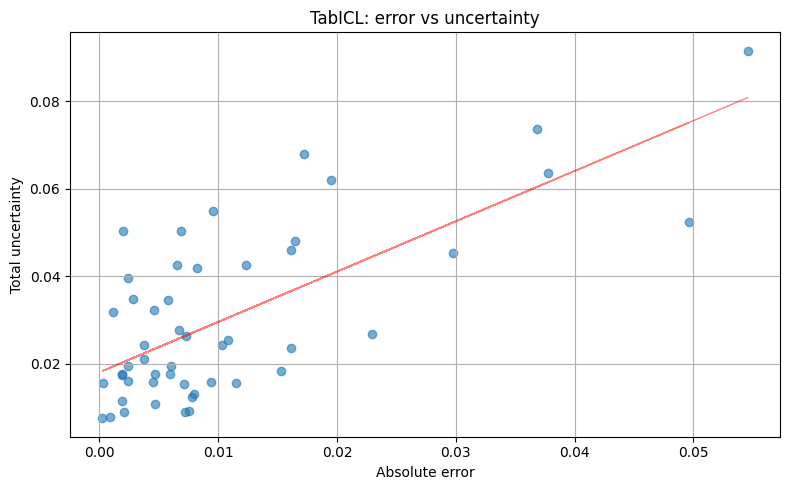

In [17]:
from sklearn.linear_model import LinearRegression

plot_df = uncertainty_df.copy()
plot_df["y_true"] = data["expt"].values
plot_df["absolute_error"] = (plot_df["pred"] - plot_df["y_true"]).abs()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["absolute_error"], plot_df["total_uncertainty"], alpha=0.6)


# regression line 
X = plot_df["absolute_error"].values.reshape(-1, 1)
y = plot_df["total_uncertainty"].values
reg = LinearRegression().fit(X, y)
plt.plot(X, reg.predict(X), color="red", linewidth=1, alpha=0.5)

plt.xlabel("Absolute error")
plt.ylabel("Total uncertainty")
plt.title("TabICL: error vs uncertainty")
plt.grid(True)
plt.tight_layout()
plt.show()